Fetching dataset (this may take a moment)...
Total images: 1288
Number of classes (people): 7
Names: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,871 (1.36 MB)

 Trainable params: 356,871 (1.36 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.3851 - loss: 1.7821 - val_accuracy: 0.4534 - val_loss: 1.6006
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.3975 - loss: 1.7209 - val_accuracy: 0.4534 - val_loss: 1.6003
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3975 - loss: 1.7285 - val_accuracy: 0.4534 - val_loss: 1.6124
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3975 - loss: 1.7245 - val_accuracy: 0.4534 - val_loss: 1.6088
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3975 - loss: 1.7269 - val_accuracy: 0.4534 - val_loss: 1.6314
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3975 - loss: 1.7270 - val_accuracy: 0.4534 - val_loss: 1.6806
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3975 - loss: 1.7235 - val_accuracy: 0.4534 - val_loss: 1.6092
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3975 - loss: 1.7279 - va

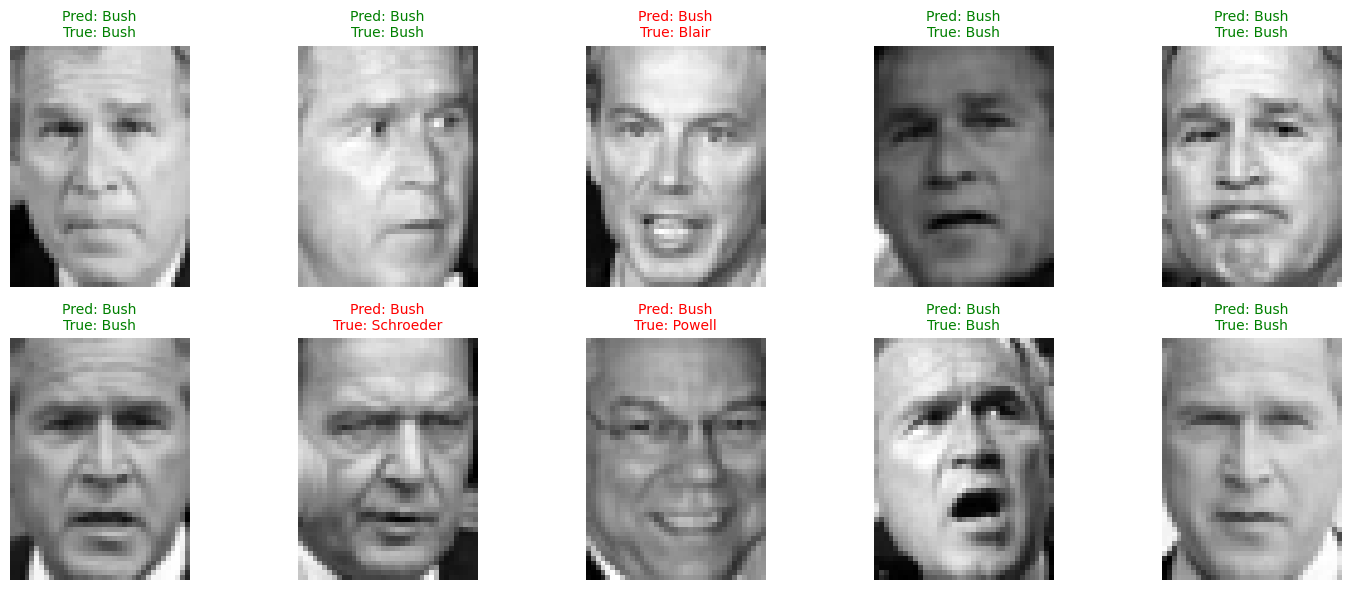

In [1]:
import tensorflow as tf  # type: ignore
from tensorflow.keras import layers, models  # type: ignore
from sklearn.datasets import fetch_lfw_people  # type: ignore
from sklearn.model_selection import train_test_split  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
import numpy as np

# ==========================================
# 1. Load and Prepare the LFW Dataset
# ==========================================
print("Fetching dataset (this may take a moment)...")
# min_faces_per_person=70 ensures we only get individuals with enough training data
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Extract images, labels, and the names of the people
X = lfw_people.images
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Total images: {X.shape[0]}")
print(f"Number of classes (people): {n_classes}")
print(f"Names: {target_names}")

# CNNs in TensorFlow expect data in the format: (batch_size, height, width, channels)
# Since these are grayscale images, we add a single channel dimension at the end.
X = X.reshape((X.shape[0], X.shape[1], X.shape[2], 1))

# Normalize pixel values to be between 0 and 1 (helps the neural network train faster)
X = X / 255.0

# Split the data into 75% training and 25% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ==========================================
# 2. Build the Convolutional Neural Network
# ==========================================
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten to feed into Dense layers
    layers.Flatten(),
    
    # Fully Connected Layer with Dropout to prevent overfitting
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Drops 50% of neurons randomly during training
    
    # Output Layer (One node per person, softmax for probabilities)
    layers.Dense(n_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 3. Train the Model
# ==========================================
print("\nStarting Training...")
history = model.fit(X_train, y_train, 
                    epochs=30, 
                    validation_data=(X_test, y_test), 
                    batch_size=32)

# ==========================================
# 4. Evaluate and Visualize Results
# ==========================================
# Evaluate on the static test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# Generate predictions for the test set
predictions = model.predict(X_test)

# Helper function to plot images with their true and predicted labels
def plot_results(images, true_labels, predictions, target_names, num_images=10):
    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].reshape(X.shape[1], X.shape[2]), cmap='gray')
        
        predicted_label = np.argmax(predictions[i])
        true_label = true_labels[i]
        
        # Color text green if correct, red if wrong
        color = 'green' if predicted_label == true_label else 'red'
        
        plt.title(f"Pred: {target_names[predicted_label].split()[-1]}\nTrue: {target_names[true_label].split()[-1]}", 
                  color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the first 10 test images
plot_results(X_test, y_test, predictions, target_names)